In [0]:
# Core Python libraries
import os
import time
import uuid
import threading
from datetime import datetime
from typing import List

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Spark SQL
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel

# Spark ML pipeline and features
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

# Spark ML models and evaluators
from pyspark.ml.classification import (
    MultilayerPerceptronClassifier,
    MultilayerPerceptronClassificationModel
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.ml.linalg import VectorUDT

# Scikit-Learn metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

# Optional Spark helper for converting vectors to arrays
try:
    from pyspark.ml.functions import vector_to_array
except Exception:
    vector_to_array = None

# Optional system resource monitoring
try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    PSUTIL_AVAILABLE = False

# Reproducibility seed
SEED = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [0]:
# Project locations
CATALOG = "new"
SCHEMA = "airgreenops"
VOLUME = "project_data"

# Output paths
ROOT = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}/airgreenops"
MODEL_ROOT = f"{ROOT}/models/mlp_high_emission"
METRICS_ROOT = f"{ROOT}/metrics/mlp_high_emission"
BENCHMARK_ROOT = f"{ROOT}/benchmarks/mlp_high_emission"

# Table names
GOLD_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`gold_flight_emissions_clean`"
MLP_RESULTS_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`mlp_high_emission_results`"
DASHBOARD_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`dashboard_mlp_high_emission_predictions`"

# Create folders
for path in [ROOT, MODEL_ROOT, METRICS_ROOT, BENCHMARK_ROOT]:
    dbutils.fs.mkdirs(path)

# Use project database
spark.sql(f"USE CATALOG `{CATALOG}`")
spark.sql(f"USE SCHEMA `{SCHEMA}`")

# Check Gold table
gold_df = spark.table(GOLD_TABLE)
row_count = gold_df.count()

print(f"Ready with {row_count:,} records from the Gold layer.")
print(f"Output path: {MODEL_ROOT}")

Ready with 20,588,136 records from the Gold layer.
Output path: /Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission


In [0]:
# Load Gold table
gold = spark.table(GOLD_TABLE)
TARGET_LABEL = "high_avoidable_emissions_flag"

# Select model features
features_for_mlp = [
    TARGET_LABEL, "month", "day_of_week", "scheduled_dep_hour",
    "origin", "airline", "aircraft_group", "distance",
    "airport_hour_departure_count_cleaned", "wind_speed", "precipitation_1hr",
    "season", "time_of_day", "congestion_level", "weather_risk_level"
]

# Check required columns
missing_cols = [c for c in features_for_mlp if c not in gold.columns]
if missing_cols:
    raise Exception(f"Missing columns in Gold table: {missing_cols}")

print(f"Loaded {gold.count():,} records from {GOLD_TABLE}")

# Check target balance
class_distribution = (
    gold.groupBy(TARGET_LABEL)
        .agg(F.count("*").alias("flight_count"))
        .withColumn(
            "class_name",
            F.when(F.col(TARGET_LABEL) == 1, "High Emission")
             .otherwise("Efficient Ops")
        )
)

# Add class percentages
total_flights = class_distribution.agg(F.sum("flight_count")).first()[0]

balance_report = (
    class_distribution
    .withColumn("percentage", F.round((F.col("flight_count") / total_flights) * 100, 2))
    .select("class_name", TARGET_LABEL, "flight_count", "percentage")
    .orderBy(TARGET_LABEL)
)

display(balance_report)

# Preview selected features
display(gold.select(features_for_mlp).limit(10))

Loaded 20,588,136 records from `new`.`airgreenops`.`gold_flight_emissions_clean`


class_name,high_avoidable_emissions_flag,flight_count,percentage
Efficient Ops,0,15484329,75.21
High Emission,1,5103807,24.79


high_avoidable_emissions_flag,month,day_of_week,scheduled_dep_hour,origin,airline,aircraft_group,distance,airport_hour_departure_count_cleaned,wind_speed,precipitation_1hr,season,time_of_day,congestion_level,weather_risk_level
0,5,4,19,AVL,G4,regional_jet,465.0,2.0,3.6,0.0,spring,evening,low,unknown
0,5,4,19,AVL,G4,narrow_body,519.0,2.0,3.6,0.0,spring,evening,low,unknown
0,5,2,7,BIL,MQ,narrow_body,1081.0,2.0,3.6,0.0,spring,morning,low,unknown
0,5,2,7,BIL,UA,regional_jet,455.0,2.0,3.6,0.0,spring,morning,low,unknown
0,5,6,14,CHS,YX,regional_jet,444.0,3.0,3.6,0.0,spring,afternoon,low,unknown
0,5,6,14,CHS,YX,regional_jet,441.0,3.0,3.6,0.0,spring,afternoon,low,unknown
0,5,6,14,CHS,DL,regional_jet,259.0,3.0,3.6,0.0,spring,afternoon,low,unknown
0,5,6,18,CHS,WN,regional_jet,472.0,7.0,3.6,0.0,spring,evening,medium,unknown
1,5,6,18,CHS,WN,narrow_body,745.0,7.0,3.6,0.0,spring,evening,medium,unknown
0,5,6,18,CHS,DL,regional_jet,259.0,7.0,3.6,0.0,spring,evening,medium,unknown


In [0]:
# Define label and sample size
LABEL_COL = "label"
TARGET_FLAG = "high_avoidable_emissions_flag"
TARGET_SAMPLE_SIZE = 1_000_000

# Output table name
MODEL_SAMPLE_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`mlp_high_emission_sample`"

# Feature groups
categorical_features = [
    "origin", "dest", "airline", "aircraft_group",
    "season", "time_of_day", "congestion_level", "weather_risk_level"
]

numeric_features = [
    "month", "day_of_week", "scheduled_dep_hour", "distance",
    "fuel_burn_kg_per_min", "airport_hour_departure_count_cleaned",
    "wind_speed", "precipitation_1hr"
]

# Prepare clean MLP dataset
mlp_base = (
    gold.select([TARGET_FLAG] + categorical_features + numeric_features)
    .where(F.col(TARGET_FLAG).isNotNull())
    .withColumn(LABEL_COL, F.col(TARGET_FLAG).cast("double"))
    .drop(TARGET_FLAG)
    .dropna()
)

# Calculate sampling fraction
base_count = mlp_base.count()
fraction = min(1.0, TARGET_SAMPLE_SIZE / base_count)

# Create training sample
mlp_sample = mlp_base.sample(
    withReplacement=False,
    fraction=fraction,
    seed=SEED
)

# Save sample table
mlp_sample.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(MODEL_SAMPLE_TABLE)

# Load saved sample
final_sample = spark.table(MODEL_SAMPLE_TABLE)

print(f"Training sample created with {final_sample.count():,} rows.")

# Check label balance
display(
    final_sample.groupBy("label")
    .agg(F.count("*").alias("count"))
    .withColumn(
        "percent",
        F.round(F.col("count") / F.sum("count").over(Window.partitionBy()), 4) * 100
    )
)

Training sample created with 999,663 rows.


label,count,percent
0.0,751930,75.22
1.0,247733,24.779999999999998


In [0]:
# Output split table
MLP_SPLIT_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`mlp_high_emission_splits`"

# Split settings
TRAIN_RATIO = 2.0
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

# Load saved sample
mlp_sample = spark.table(MODEL_SAMPLE_TABLE)

# Add random split column
mlp_with_labels = mlp_sample.withColumn("split_rand", F.rand(SEED))

# Create train, validation, and test sets
train_set = mlp_with_labels.filter(F.col("split_rand") < TRAIN_FRAC)

val_set = mlp_with_labels.filter(
    (F.col("split_rand") >= TRAIN_FRAC) &
    (F.col("split_rand") < TRAIN_FRAC + VAL_FRAC)
)

test_set = mlp_with_labels.filter(
    F.col("split_rand") >= TRAIN_FRAC + VAL_FRAC
)

# Cast label and numeric columns
def align_types(df):
    df = df.withColumn(LABEL_COL, F.col(LABEL_COL).cast("double"))

    for col_name in numeric_features:
        df = df.withColumn(col_name, F.col(col_name).cast("double"))

    return df

# Split training classes
pos_train = align_types(train_set.filter(F.col(LABEL_COL) == 1.0))
neg_train = align_types(train_set.filter(F.col(LABEL_COL) == 0.0))

# Balance training set
pos_count = pos_train.count()
neg_count = neg_train.count()

fraction = min(1.0, (pos_count * TRAIN_RATIO) / neg_count)

train_balanced = (
    pos_train
    .unionByName(neg_train.sample(False, fraction, seed=SEED))
    .withColumn("set", F.lit("train"))
)

# Prepare validation and test sets
val_final = align_types(val_set).withColumn("set", F.lit("val"))
test_final = align_types(test_set).withColumn("set", F.lit("test"))

# Combine all splits
final_splits = (
    train_balanced
    .unionByName(val_final)
    .unionByName(test_final)
    .drop("split_rand")
)

# Save split table
final_splits.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(MLP_SPLIT_TABLE)

print("Split table saved successfully.")

# Check split distribution
display(
    spark.table(MLP_SPLIT_TABLE)
    .groupBy("set", "label")
    .agg(F.count("*").alias("count"))
    .orderBy("set", "label")
)

Split table saved successfully.


set,label,count
test,0.0,112486
test,1.0,37116
train,0.0,346818
train,1.0,173458
val,0.0,112636
val,1.0,37159


In [0]:

# Output prepared table
MLP_PREPARED_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`mlp_high_emission_prepared`"

# Numeric features
numeric_cols = [
    "month",
    "day_of_week",
    "scheduled_dep_hour",
    "distance",
    "fuel_burn_kg_per_min",
    "airport_hour_departure_count_cleaned",
    "wind_speed",
    "precipitation_1hr"
]

# Categorical features
categorical_cols = [
    "origin", "dest", "airline", "aircraft_group",
    "season", "time_of_day", "congestion_level", "weather_risk_level"
]

# Load training data
train_raw = spark.table(MLP_SPLIT_TABLE).filter(F.col("set") == "train")

# Encode categorical columns
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

# Scale numeric columns
num_assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="num_vec",
    handleInvalid="keep"
)

num_scaler = StandardScaler(
    inputCol="num_vec",
    outputCol="num_scaled",
    withMean=False,
    withStd=True
)

# Build final feature vector
final_assembler = VectorAssembler(
    inputCols=["num_scaled"] + [f"{c}_ohe" for c in categorical_cols],
    outputCol="features",
    handleInvalid="keep"
)

# Train feature pipeline
pipeline = Pipeline(
    stages=indexers + encoders + [num_assembler, num_scaler, final_assembler]
)

pipeline_model = pipeline.fit(train_raw)

# Save pipeline
PIPELINE_PATH = f"{MODEL_ROOT}/feature_pipeline"
pipeline_model.write().overwrite().save(PIPELINE_PATH)

# Apply pipeline to all splits
prepared_df = pipeline_model.transform(spark.table(MLP_SPLIT_TABLE))

# Select final columns
final_cols = ["set", "label", "features"] + categorical_cols + numeric_cols

# Save prepared table
prepared_df.select(*final_cols) \
    .write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(MLP_PREPARED_TABLE)

# Get model input size
prepared_table = spark.table(MLP_PREPARED_TABLE)
INPUT_SIZE = len(prepared_table.select("features").first()[0])

print(f"Feature engineering complete with {prepared_table.count():,} rows.")
print(f"Input layer size: {INPUT_SIZE}")

display(
    prepared_table
    .select("set", "label", "origin", "month", "features")
    .limit(5)
)

Feature engineering complete with 819,673 rows.
Input layer size: 759


set,label,origin,month,features
train,1.0,DCA,1.0,"Map(vectorType -> sparse, length -> 759, indices -> List(0, 1, 2, 3, 4, 5, 6, 21, 366, 727, 741, 747, 748, 752, 755), values -> List(0.2936094863135348, 0.9974811326249073, 1.2239240776338165, 0.8994891420715382, 4.223424417741773, 1.6834031851543623, 2.899370388789795, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
train,1.0,LAX,1.0,"Map(vectorType -> sparse, length -> 759, indices -> List(0, 1, 2, 3, 4, 5, 6, 13, 386, 728, 741, 747, 749, 752, 756), values -> List(0.2936094863135348, 2.9924433978747222, 2.447848155267633, 3.851194827662783, 4.223424417741773, 1.4358438932198974, 2.4966800570134344, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
train,1.0,MDW,1.0,"Map(vectorType -> sparse, length -> 759, indices -> List(0, 1, 2, 3, 4, 5, 6, 35, 373, 726, 741, 747, 748, 753, 755), values -> List(0.2936094863135348, 0.49874056631245367, 1.0199367313615137, 2.501138912414643, 4.223424417741773, 0.29707115032135806, 2.899370388789795, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
train,1.0,HDN,1.0,"Map(vectorType -> sparse, length -> 759, indices -> List(0, 1, 2, 3, 4, 5, 6, 187, 367, 726, 742, 747, 748, 754, 755), values -> List(0.2936094863135348, 0.49874056631245367, 2.0398734627230275, 0.2318610037149669, 2.8156162784945153, 0.04951185838689301, 2.899370388789795, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
train,1.0,SLC,1.0,"Map(vectorType -> sparse, length -> 759, indices -> List(0, 1, 2, 3, 4, 5, 6, 27, 371, 727, 741, 747, 748, 752, 755), values -> List(0.2936094863135348, 3.491183964187176, 2.24386080899533, 0.9701985261831948, 4.223424417741773, 1.8319387603150414, 2.899370388789795, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"


In [0]:

# Load prepared data
prepared = spark.table(MLP_PREPARED_TABLE)

# Prepare train and validation sets
train_df = (
    prepared.filter(F.col("set") == "train")
    .select("label", "features")
    .persist()
)

val_df = (
    prepared.filter(F.col("set") == "val")
    .select("label", "features")
    .persist()
)

# Baseline MLP structure
BASELINE_LAYERS = [INPUT_SIZE, 32, 2]

# Create baseline model
baseline_mlp = MultilayerPerceptronClassifier(
    layers=BASELINE_LAYERS,
    maxIter=50,
    blockSize=128,
    seed=SEED
)

# Train model
train_rows = train_df.count()
print(f"Starting baseline training on {train_rows:,} records...")

start_time = time.time()
baseline_model = baseline_mlp.fit(train_df)
train_time = time.time() - start_time

# Save model
BASELINE_PATH = f"{MODEL_ROOT}/baseline_mlp"
baseline_model.write().overwrite().save(BASELINE_PATH)

# Predict validation data
predictions = baseline_model.transform(val_df)

# Evaluate model
def evaluate_metric(preds, metric):
    return MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    ).evaluate(preds)

acc = evaluate_metric(predictions, "accuracy")
f1 = evaluate_metric(predictions, "f1")

auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(predictions)

print(f"Training complete in {train_time:.2f}s")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Save benchmark results
metrics_data = [(
    "baseline_mlp",
    str(BASELINE_LAYERS),
    train_time,
    acc,
    f1,
    auc,
    train_rows
)]

metrics_cols = [
    "model_name",
    "layers",
    "train_seconds",
    "accuracy",
    "f1_score",
    "auc",
    "training_rows"
]

baseline_metrics_df = spark.createDataFrame(metrics_data, metrics_cols)

baseline_metrics_df.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(MLP_RESULTS_TABLE)

# Show confusion matrix
display(
    predictions.groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)

# Clear cache
train_df.unpersist()
val_df.unpersist()

Starting baseline training on 520,276 records...
Training complete in 128.88s
Accuracy: 0.7434
F1 Score: 0.7182
AUC: 0.6910


label,prediction,count
0.0,0.0,101085
0.0,1.0,11551
1.0,0.0,26891
1.0,1.0,10268


DataFrame[label: double, features: vector]

In [0]:
# Load prepared data
prepared = spark.table(MLP_PREPARED_TABLE)

# Prepare train and validation sets
train_df = (
    prepared.filter(F.col("set") == "train")
    .select("label", "features")
    .persist()
)

val_df = (
    prepared.filter(F.col("set") == "val")
    .select("label", "features")
    .persist()
)

# Deep MLP structure
DEEP_LAYERS = [INPUT_SIZE, 128, 64, 32, 2]

# Create deep model
deep_mlp = MultilayerPerceptronClassifier(
    layers=DEEP_LAYERS,
    maxIter=120,
    blockSize=256,
    seed=SEED
)

# Train model
train_rows = train_df.count()
print(f"Starting deep MLP training on {train_rows:,} records...")

start_time = time.time()
deep_model = deep_mlp.fit(train_df)
train_time = time.time() - start_time

# Save model
DEEP_PATH = f"{MODEL_ROOT}/deep_mlp"
deep_model.write().overwrite().save(DEEP_PATH)

# Predict validation data
predictions = deep_model.transform(val_df)

# Evaluate model
def evaluate_metric(preds, metric):
    return MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    ).evaluate(preds)

acc = evaluate_metric(predictions, "accuracy")
f1 = evaluate_metric(predictions, "f1")

auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(predictions)

print(f"Deep MLP complete in {train_time:.2f}s")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Save metrics
metrics_data = [(
    "deep_mlp",
    str(DEEP_LAYERS),
    train_time,
    acc,
    f1,
    auc,
    train_rows
)]

metrics_cols = [
    "model_name",
    "layers",
    "train_seconds",
    "accuracy",
    "f1_score",
    "auc",
    "training_rows"
]

deep_metrics_df = spark.createDataFrame(metrics_data, metrics_cols)

deep_metrics_df.write.format("delta") \
    .mode("append") \
    .option("mergeSchema", "true") \
    .saveAsTable(MLP_RESULTS_TABLE)

# Show confusion matrix
display(
    predictions.groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)

# Clear cache
train_df.unpersist()
val_df.unpersist()

Starting deep MLP training on 520,276 records...


Deep MLP complete in 1155.48s
Accuracy: 0.7452
F1 Score: 0.7202
AUC: 0.6967


label,prediction,count
0.0,0.0,101224
0.0,1.0,11412
1.0,0.0,26757
1.0,1.0,10402


DataFrame[label: double, features: vector]

In [0]:
# Load prepared data
prepared = spark.table(MLP_PREPARED_TABLE)

# Prepare train and validation sets
train_df = (
    prepared.where(F.col("set") == "train")
    .select("label", "features")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

val_df = (
    prepared.where(F.col("set") == "val")
    .select("label", "features")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

# Wide MLP structure
WIDE_LAYERS = [INPUT_SIZE, 256, 128, 2]

# Create wide model
wide_mlp = MultilayerPerceptronClassifier(
    labelCol="label",
    featuresCol="features",
    layers=WIDE_LAYERS,
    maxIter=50,
    blockSize=128,
    stepSize=0.03,
    seed=SEED
)

# Train model
train_rows = train_df.count()
print(f"Starting wide MLP training on {train_rows:,} rows...")

start_time = time.time()
wide_model = wide_mlp.fit(train_df)
train_time = time.time() - start_time

# Save model
WIDE_MODEL_PATH = f"{MODEL_ROOT}/wide_mlp"
wide_model.write().overwrite().save(WIDE_MODEL_PATH)

# Predict validation data
predictions = wide_model.transform(val_df)

# Evaluate model
def get_metric(preds, metric_name):
    if metric_name == "auc":
        return BinaryClassificationEvaluator(
            labelCol="label",
            rawPredictionCol="rawPrediction",
            metricName="areaUnderROC"
        ).evaluate(preds)

    return MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_name
    ).evaluate(preds)

metrics = {
    "acc": get_metric(predictions, "accuracy"),
    "f1": get_metric(predictions, "f1"),
    "auc": get_metric(predictions, "auc")
}

print(f"Wide MLP complete in {train_time:.2f}s")
print(f"Accuracy: {metrics['acc']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print(f"AUC: {metrics['auc']:.4f}")

# Save metrics
wide_metrics_df = spark.createDataFrame([(
    "wide_mlp",
    str(WIDE_LAYERS),
    train_time,
    metrics["acc"],
    metrics["f1"],
    metrics["auc"],
    train_rows
)], [
    "model_name",
    "layers",
    "train_seconds",
    "accuracy",
    "f1_score",
    "auc",
    "training_rows"
])

wide_metrics_df.write.format("delta") \
    .mode("append") \
    .option("mergeSchema", "true") \
    .saveAsTable(MLP_RESULTS_TABLE)

# Show confusion matrix
display(
    predictions.groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)

# Clear cache
train_df.unpersist()
val_df.unpersist()

Starting wide MLP training on 520,276 rows...


Wide MLP complete in 986.29s
Accuracy: 0.7443
F1 Score: 0.7128
AUC: 0.6819


label,prediction,count
0.0,0.0,102492
0.0,1.0,10144
1.0,0.0,28160
1.0,1.0,8999


DataFrame[label: double, features: vector]

Validation rows: 149795
Evaluating baseline_mlp from /Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission/baseline_mlp

Classification report for baseline_mlp:
                   precision    recall  f1-score   support

not_high_emission       0.79      0.90      0.84    112636
    high_emission       0.47      0.28      0.35     37159

         accuracy                           0.74    149795
        macro avg       0.63      0.59      0.59    149795
     weighted avg       0.71      0.74      0.72    149795



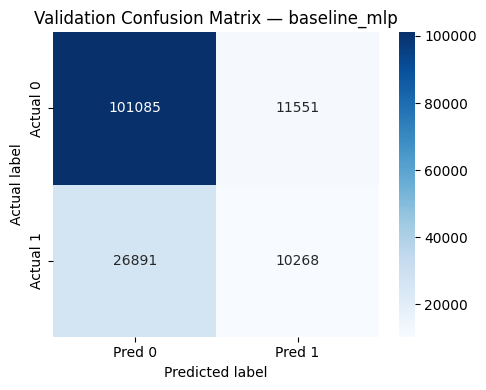

Evaluating deep_mlp from /Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission/deep_mlp

Classification report for deep_mlp:
                   precision    recall  f1-score   support

not_high_emission       0.79      0.90      0.84    112636
    high_emission       0.48      0.28      0.35     37159

         accuracy                           0.75    149795
        macro avg       0.63      0.59      0.60    149795
     weighted avg       0.71      0.75      0.72    149795



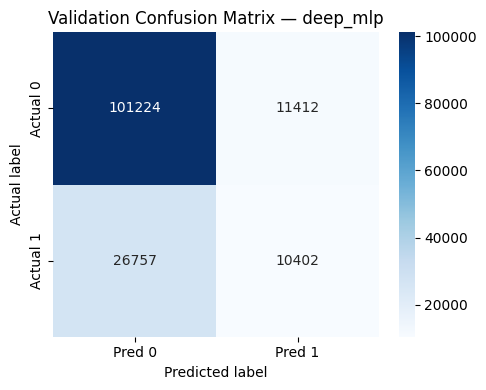

Evaluating wide_mlp from /Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission/wide_mlp

Classification report for wide_mlp:
                   precision    recall  f1-score   support

not_high_emission       0.78      0.91      0.84    112636
    high_emission       0.47      0.24      0.32     37159

         accuracy                           0.74    149795
        macro avg       0.63      0.58      0.58    149795
     weighted avg       0.71      0.74      0.71    149795



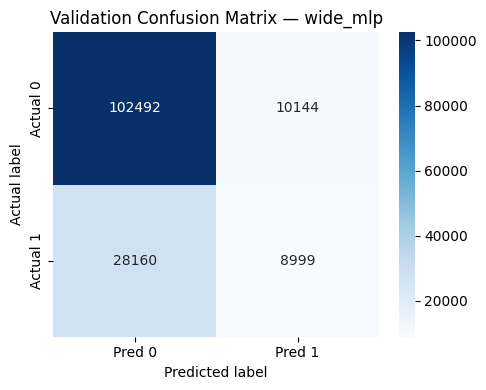

Saved model comparison results.
Results table:          `new`.`airgreenops`.`mlp_high_emission_results`
Confusion matrix table: `new`.`airgreenops`.`mlp_high_emission_confusion_matrix`


model_name,model_path,validation_accuracy,validation_precision_high_emission,validation_recall_high_emission,validation_f1_high_emission,validation_auc,validation_inference_seconds,true_negative,false_positive,false_negative,true_positive
deep_mlp,/Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission/deep_mlp,0.7451917620748356,0.4768497295314935,0.27993218332032616,0.3527716073457345,0.696685115047864,0.05890083312988281,101224,11412,26757,10402
baseline_mlp,/Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission/baseline_mlp,0.7433692713374945,0.47059901920344654,0.27632605829005086,0.3481976330157008,0.6909669853953491,0.06688475608825684,101085,11551,26891,10268
wide_mlp,/Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission/wide_mlp,0.7442905303915351,0.4700935067648749,0.2421755160257273,0.31966892827963483,0.6818903090368734,0.06058359146118164,102492,10144,28160,8999


model_name,dataset,actual_label,predicted_label,count
baseline_mlp,validation,0,0,101085
baseline_mlp,validation,0,1,11551
baseline_mlp,validation,1,0,26891
baseline_mlp,validation,1,1,10268
deep_mlp,validation,0,0,101224
deep_mlp,validation,0,1,11412
deep_mlp,validation,1,0,26757
deep_mlp,validation,1,1,10402
wide_mlp,validation,0,0,102492
wide_mlp,validation,0,1,10144


Best validation model selected:
Model name: deep_mlp
Model path: /Volumes/new/airgreenops/project_data/airgreenops/models/mlp_high_emission/deep_mlp
Validation F1 high-emission: 0.3528
Validation AUC: 0.6967


In [0]:
# Compare the baseline, deep, and wide MLP models using validation performance metrics

# Confusion matrix output table
MLP_CONFUSION_MATRIX_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`mlp_high_emission_confusion_matrix`"

# Load the prepared MLP dataset
prepared = spark.table(MLP_PREPARED_TABLE)

# Use only the validation split for model comparison
validation_df = (
    prepared
    .where(F.col("set") == "val")
    .select(LABEL_COL, "features")
)

print("Validation rows:", validation_df.count())

# Define the saved model locations
saved_model_paths = {
    "baseline_mlp": f"{MODEL_ROOT}/baseline_mlp",
    "deep_mlp": f"{MODEL_ROOT}/deep_mlp",
    "wide_mlp": f"{MODEL_ROOT}/wide_mlp"
}

# Create an evaluator to calculate AUC for binary classification
auc_evaluator = BinaryClassificationEvaluator(
    labelCol=LABEL_COL,
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

# Lists to store model metrics and confusion matrix results
metrics_rows = []
confusion_rows = []

# Evaluate each trained MLP model one by one
for model_name, model_path in saved_model_paths.items():

    print(f"Evaluating {model_name} from {model_path}")

    # Load the trained model from storage
    model = MultilayerPerceptronClassificationModel.load(model_path)

    # Run prediction on the validation data and record inference time
    start_time = time.time()
    pred = model.transform(validation_df)
    inference_seconds = time.time() - start_time

    # Calculate AUC score
    auc_score = auc_evaluator.evaluate(pred)

    # Convert prediction results to Pandas for Scikit-Learn evaluation
    pred_pdf = (
        pred
        .select(
            F.col(LABEL_COL).cast("int").alias("label"),
            F.col("prediction").cast("int").alias("prediction")
        )
        .toPandas()
    )

    # Separate actual labels and predicted labels
    y_true = pred_pdf["label"]
    y_pred = pred_pdf["prediction"]

    # Calculate standard classification metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    # Build confusion matrix values
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Save overall model performance metrics
    metrics_rows.append({
        "model_name": model_name,
        "model_path": model_path,
        "validation_accuracy": float(acc),
        "validation_precision_high_emission": float(precision),
        "validation_recall_high_emission": float(recall),
        "validation_f1_high_emission": float(f1),
        "validation_auc": float(auc_score),
        "validation_inference_seconds": float(inference_seconds),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp)
    })

    # Save confusion matrix values in table format
    confusion_rows.extend([
        {"model_name": model_name, "dataset": "validation", "actual_label": 0, "predicted_label": 0, "count": int(tn)},
        {"model_name": model_name, "dataset": "validation", "actual_label": 0, "predicted_label": 1, "count": int(fp)},
        {"model_name": model_name, "dataset": "validation", "actual_label": 1, "predicted_label": 0, "count": int(fn)},
        {"model_name": model_name, "dataset": "validation", "actual_label": 1, "predicted_label": 1, "count": int(tp)},
    ])

    # Print a detailed classification report for each model
    print()
    print(f"Classification report for {model_name}:")
    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["not_high_emission", "high_emission"],
        zero_division=0
    ))

    # Plot the confusion matrix for visual model comparison
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.title(f"Validation Confusion Matrix — {model_name}")
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.tight_layout()
    plt.show()

# Convert collected results into Spark DataFrames
metrics_sdf = spark.createDataFrame(pd.DataFrame(metrics_rows))
confusion_sdf = spark.createDataFrame(pd.DataFrame(confusion_rows))

# Save model comparison metrics as Delta tables
metrics_sdf.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(MLP_RESULTS_TABLE)

confusion_sdf.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(MLP_CONFUSION_MATRIX_TABLE)

print("Saved model comparison results.")
print(f"Results table:          {MLP_RESULTS_TABLE}")
print(f"Confusion matrix table: {MLP_CONFUSION_MATRIX_TABLE}")

# Display the model comparison results
display(
    spark.table(MLP_RESULTS_TABLE)
    .orderBy(F.desc("validation_f1_high_emission"), F.desc("validation_auc"))
)

# Display the confusion matrix table
display(
    spark.table(MLP_CONFUSION_MATRIX_TABLE)
    .orderBy("model_name", "actual_label", "predicted_label")
)

# Select the best model based on validation F1 score, then AUC
best_model_row = (
    spark.table(MLP_RESULTS_TABLE)
    .orderBy(F.desc("validation_f1_high_emission"), F.desc("validation_auc"))
    .first()
)

BEST_MODEL_NAME = best_model_row["model_name"]
BEST_MODEL_PATH = best_model_row["model_path"]

print("Best validation model selected:")
print(f"Model name: {BEST_MODEL_NAME}")
print(f"Model path: {BEST_MODEL_PATH}")
print(f"Validation F1 high-emission: {best_model_row['validation_f1_high_emission']:.4f}")
print(f"Validation AUC: {best_model_row['validation_auc']:.4f}")

Final Comparative MLP Assessment
Test set size used for all MLP comparisons: 149,602

Loss History by Model

Loss Report for Baseline MLP
--------------------------------------------------------------------------------
Loss history points: 51
Initial loss:        0.638943
Final loss:          0.582089
Minimum loss:        0.582089
Full loss history:   [0.638943, 0.63702, 0.631766, 0.617908, 0.61028, 0.609831, 0.609357, 0.608292, 0.60636, 0.603934, 0.600026, 0.596683, 0.595373, 0.594099, 0.593412, 0.593054, 0.592973, 0.592431, 0.592226, 0.590917, 0.589374, 0.588696, 0.588285, 0.587999, 0.587866, 0.587721, 0.587065, 0.586868, 0.586604, 0.585859, 0.585125, 0.584968, 0.584748, 0.584689, 0.584528, 0.584444, 0.584228, 0.584052, 0.583873, 0.583727, 0.583488, 0.583208, 0.582945, 0.582882, 0.58275, 0.582555, 0.582332, 0.582289, 0.582206, 0.582165, 0.582089]

Loss Report for Deep MLP
--------------------------------------------------------------------------------
Loss history points: 121
Initial

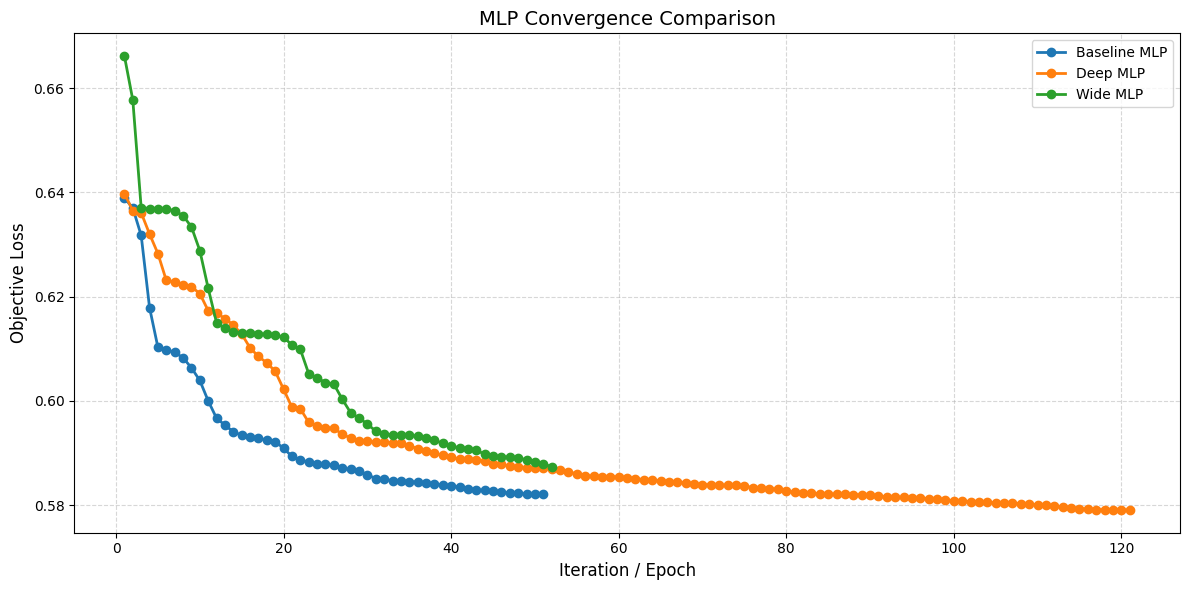


Evaluating: Baseline MLP
AUC ROC score source column: probability
AUC ROC: 0.692621
Final objective loss: 0.582089
Minimum objective loss: 0.582089

Classification Report:
               precision    recall  f1-score   support

    Efficient       0.79      0.90      0.84    112486
High Emission       0.47      0.27      0.35     37116

     accuracy                           0.74    149602
    macro avg       0.63      0.59      0.59    149602
 weighted avg       0.71      0.74      0.72    149602

Confusion Matrix Counts:
True Efficient predicted Efficient:           101077
True Efficient predicted High Emission:       11409
True High Emission predicted Efficient:       26946
True High Emission predicted High Emission:   10170

Evaluating: Deep MLP
AUC ROC score source column: probability
AUC ROC: 0.697155
Final objective loss: 0.579086
Minimum objective loss: 0.579086

Classification Report:
               precision    recall  f1-score   support

    Efficient       0.79      0.90 

Model,AUC ROC,Loss Points,Initial Loss,Final Loss,Minimum Loss,Accuracy,Balanced Accuracy,Efficient Precision,Efficient Recall,Efficient F1,High Emission Precision,High Emission Recall,High Emission F1,Macro F1,Weighted F1,TN,FP,FN,TP
Baseline MLP,0.692621,51,0.638943,0.582089,0.582089,0.74362,0.58629,0.789522,0.898574,0.840526,0.471292,0.274006,0.346537,0.593531,0.717968,101077,11409,26946,10170
Deep MLP,0.697155,121,0.63979,0.579086,0.579086,0.745398,0.588971,0.790711,0.899463,0.841588,0.477524,0.278478,0.351798,0.596693,0.720072,101177,11309,26780,10336
Wide MLP,0.683865,52,0.666169,0.587382,0.587382,0.745211,0.576598,0.784627,0.911278,0.843223,0.473601,0.241917,0.32025,0.581736,0.713474,102506,9980,28137,8979


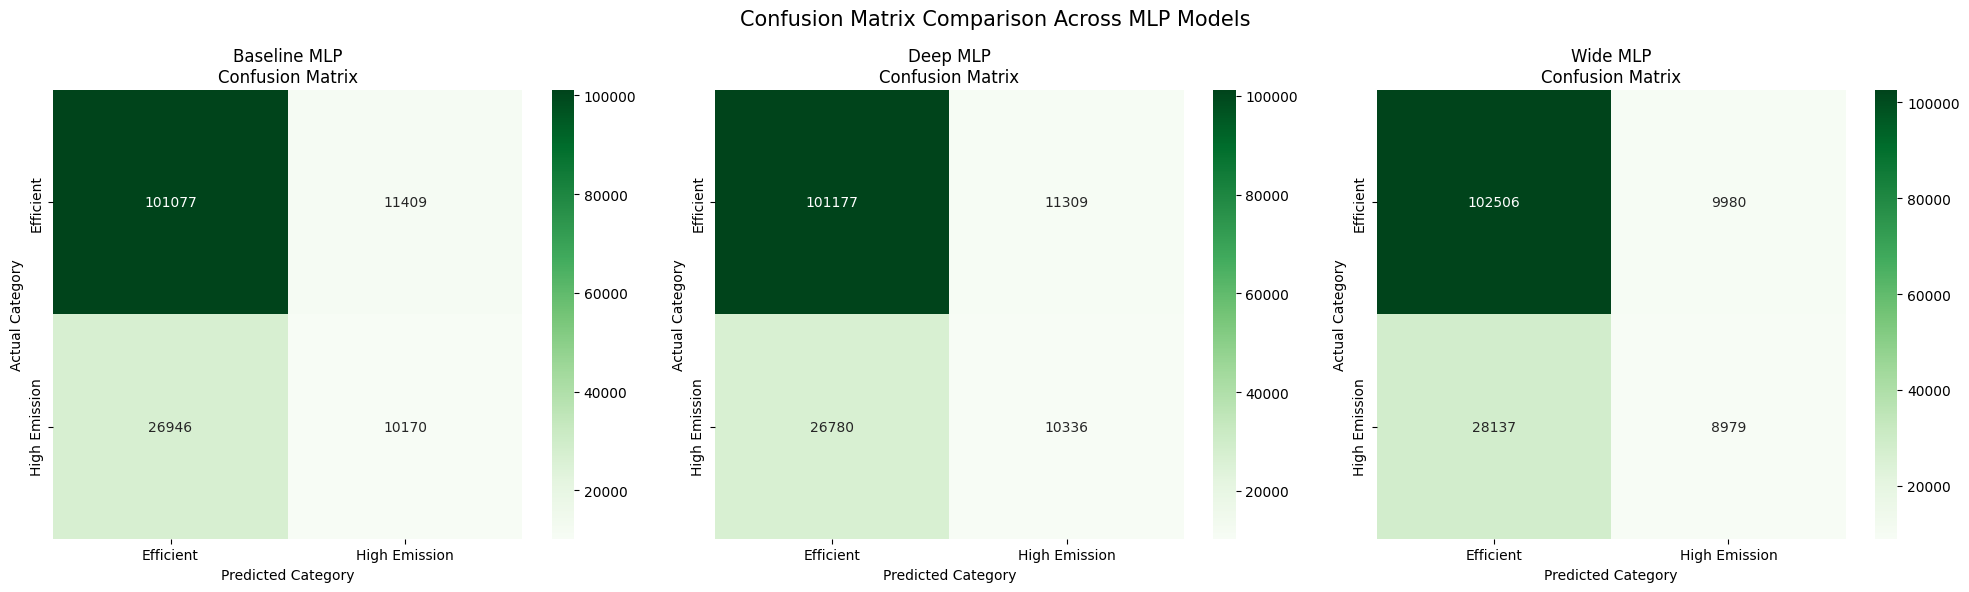

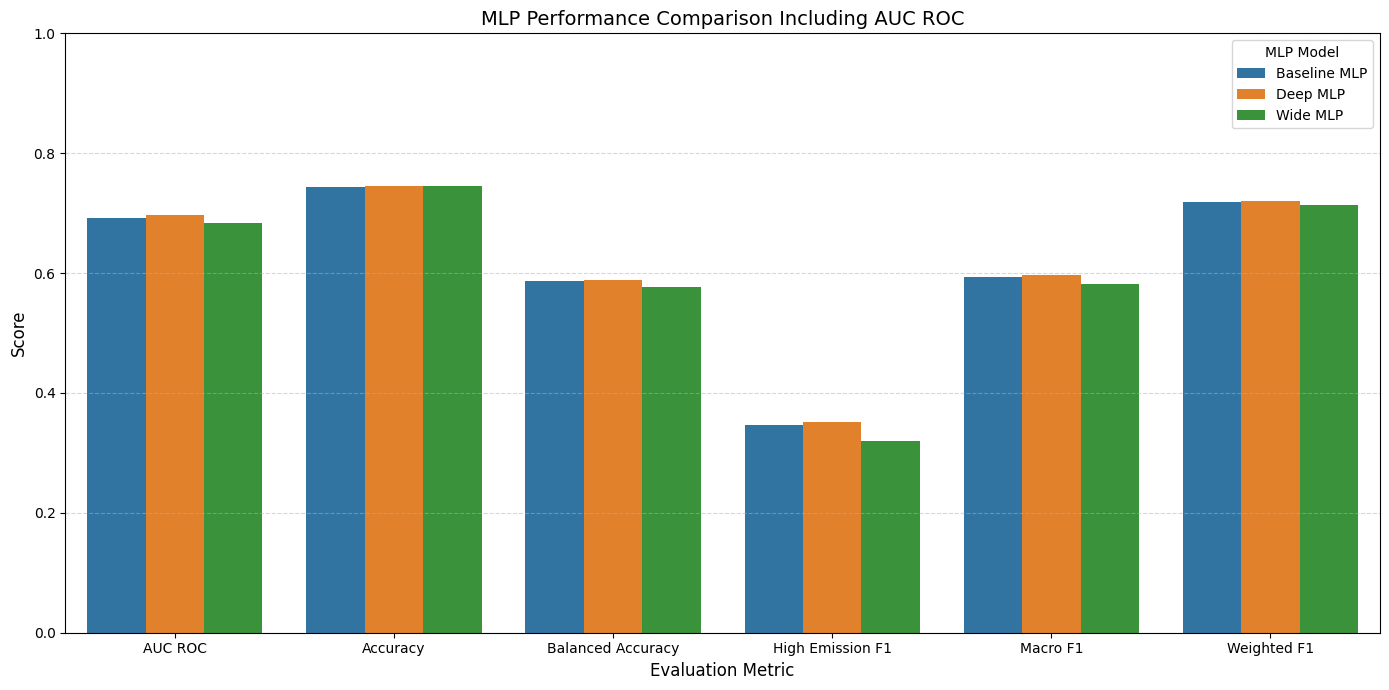


Best Model Summary
Best AUC ROC Model:               Deep MLP
Best Accuracy Model:              Deep MLP
Best Macro F1 Model:              Deep MLP
Best High Emission F1 Model:      Deep MLP
Best Weighted F1 Model:           Deep MLP
Lowest Final Loss Model:          Deep MLP

Saved comparison table to:
/tmp/mlp_comparison_results_with_auc_loss.csv


DataFrame[set: string, label: double, features: vector, origin: string, dest: string, airline: string, aircraft_group: string, season: string, time_of_day: string, congestion_level: string, weather_risk_level: string, month: double, day_of_week: double, scheduled_dep_hour: double, distance: double, fuel_burn_kg_per_min: double, airport_hour_departure_count_cleaned: double, wind_speed: double, precipitation_1hr: double]

In [0]:
# Final comparative MLP assessment
# This cell compares the Baseline, Deep, and Wide MLP models using loss history,
# AUC ROC, classification reports, confusion matrices, and a final metrics table.


# Convert different Spark, Java, or Python history formats into a normal Python list
def _to_float_list(obj):
    if obj is None:
        return []

    try:
        return [float(x) for x in obj]
    except Exception:
        pass

    try:
        return [float(x) for x in obj.toArray()]
    except Exception:
        pass

    try:
        return [float(obj.apply(i)) for i in range(obj.size())]
    except Exception:
        pass

    return []


# Extract possible model objects from raw models, pipelines, or wrapped models
def _candidate_models(model_obj):
    seen = set()
    queue = [model_obj]

    while queue:
        obj = queue.pop(0)

        if obj is None:
            continue

        obj_id = id(obj)
        if obj_id in seen:
            continue

        seen.add(obj_id)
        yield obj

        # Check inside PipelineModel stages if the model is part of a pipeline
        try:
            if hasattr(obj, "stages"):
                queue.extend(list(reversed(obj.stages)))
        except Exception:
            pass

        # Check common wrapper attributes that may contain the trained model
        for attr in ["bestModel", "model", "mlpModel", "_model"]:
            try:
                wrapped = getattr(obj, attr)
                if wrapped is not None and not callable(wrapped):
                    queue.append(wrapped)
            except Exception:
                pass


# Fetch the objective loss history from the trained MLP model when available
def fetch_loss_history(model_obj, fallback_history_names=None):
    if fallback_history_names is None:
        fallback_history_names = []

    for candidate in _candidate_models(model_obj):

        # Try the standard PySpark summary path
        try:
            summary = getattr(candidate, "summary")

            if callable(summary):
                summary = summary()

            history = getattr(summary, "objectiveHistory", None)

            if callable(history):
                history = history()

            history = _to_float_list(history)

            if len(history) > 0:
                return history
        except Exception:
            pass

        # Try the Java object summary path used internally by Spark
        try:
            java_obj = getattr(candidate, "_java_obj", None)

            if java_obj is not None:
                try:
                    has_summary = bool(java_obj.hasSummary())
                except Exception:
                    has_summary = True

                if has_summary:
                    java_summary = java_obj.summary()
                    history = java_summary.objectiveHistory()
                    history = _to_float_list(history)

                    if len(history) > 0:
                        return history
        except Exception:
            pass

        # Try older or direct objective history methods if available
        try:
            if hasattr(candidate, "getObjectiveHistory"):
                history = candidate.getObjectiveHistory()
                history = _to_float_list(history)

                if len(history) > 0:
                    return history
        except Exception:
            pass

    # Use fallback notebook variables if the model no longer stores history
    for var_name in fallback_history_names:
        try:
            history = globals().get(var_name, None)
            history = _to_float_list(history)

            if len(history) > 0:
                return history
        except Exception:
            pass

    return []


# Create a simple summary of the loss history
def summarize_loss(loss_values):
    if len(loss_values) == 0:
        return {
            "Loss Points": 0,
            "Initial Loss": np.nan,
            "Final Loss": np.nan,
            "Minimum Loss": np.nan
        }

    return {
        "Loss Points": len(loss_values),
        "Initial Loss": float(loss_values[0]),
        "Final Loss": float(loss_values[-1]),
        "Minimum Loss": float(min(loss_values))
    }


# Print the loss history in a readable format
def print_loss_report(model_name, loss_values):
    print(f"\nLoss Report for {model_name}")
    print("-" * 80)

    if len(loss_values) == 0:
        print("Loss history: NOT AVAILABLE")
        print("Reason: Spark may not retain objectiveHistory after loading/saving models.")
        print("Fix: store model.summary.objectiveHistory immediately after fitting.")
        return

    rounded_loss_history = [round(float(x), 6) for x in loss_values]

    print(f"Loss history points: {len(loss_values)}")
    print(f"Initial loss:        {loss_values[0]:.6f}")
    print(f"Final loss:          {loss_values[-1]:.6f}")
    print(f"Minimum loss:        {min(loss_values):.6f}")
    print(f"Full loss history:   {rounded_loss_history}")


# Extract the score of the positive class from a Spark vector or numeric value
def _extract_pos_score_python(v):
    if v is None:
        return None

    try:
        return float(v[1])
    except Exception:
        pass

    try:
        return float(v)
    except Exception:
        pass

    return None


# Register a UDF as a fallback method for extracting the positive-class score
extract_pos_score_udf = F.udf(_extract_pos_score_python, DoubleType())


# Add a numeric positive-class score column for AUC ROC calculation
def add_positive_score_column(df, output_col="p_high_emission"):

    # Prefer probability column if available, otherwise use rawPrediction
    if "probability" in df.columns:
        source_col = "probability"
    elif "rawPrediction" in df.columns:
        source_col = "rawPrediction"
    else:
        return df.withColumn(output_col, F.lit(None).cast("double")), "NO_SCORE_COLUMN_FOUND"

    source_dtype = df.schema[source_col].dataType

    # If the score column is a vector, extract index 1 as the positive-class score
    if isinstance(source_dtype, VectorUDT):
        if vector_to_array is not None:
            scored_df = df.withColumn(
                output_col,
                vector_to_array(F.col(source_col)).getItem(1).cast("double")
            )
        else:
            scored_df = df.withColumn(
                output_col,
                extract_pos_score_udf(F.col(source_col))
            )
    else:
        scored_df = df.withColumn(
            output_col,
            F.col(source_col).cast("double")
        )

    return scored_df, source_col


# Define the trained MLP models to compare
mlp_models = {
    "Baseline MLP": baseline_model,
    "Deep MLP": deep_model,
    "Wide MLP": wide_model
}

# Define class labels and readable class names
class_labels = [0, 1]
class_names = ["Efficient", "High Emission"]


# Load and cache the shared test dataset used for all model comparisons
test_data = (
    spark.table(MLP_PREPARED_TABLE)
    .filter(F.col("set") == "test")
    .cache()
)

# Count the test records to confirm the evaluation sample size
test_count = test_data.count()

print("=" * 80)
print("Final Comparative MLP Assessment")
print("=" * 80)
print(f"Test set size used for all MLP comparisons: {test_count:,}")


# Collect loss histories for each model
loss_histories = {
    "Baseline MLP": fetch_loss_history(
        baseline_model,
        fallback_history_names=["baseline_loss_history", "b_loss", "baseline_history"]
    ),
    "Deep MLP": fetch_loss_history(
        deep_model,
        fallback_history_names=["deep_loss_history", "d_loss", "deep_history"]
    ),
    "Wide MLP": fetch_loss_history(
        wide_model,
        fallback_history_names=["wide_loss_history", "w_loss", "wide_history"]
    )
}


# Print loss history details for each model
print("\n" + "=" * 80)
print("Loss History by Model")
print("=" * 80)

for model_name, loss_values in loss_histories.items():
    print_loss_report(model_name, loss_values)


# Plot the loss curves for models where objective history is available
plt.figure(figsize=(12, 6))

plotted_any_loss = False

for model_name, loss_values in loss_histories.items():
    if len(loss_values) > 0:
        epochs = range(1, len(loss_values) + 1)
        plt.plot(epochs, loss_values, marker="o", linewidth=2, label=model_name)
        plotted_any_loss = True

plt.title("MLP Convergence Comparison", fontsize=14)
plt.xlabel("Iteration / Epoch", fontsize=12)
plt.ylabel("Objective Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Show legend only if at least one loss curve was plotted
if plotted_any_loss:
    plt.legend()
else:
    plt.text(
        0.5,
        0.5,
        "No objective history found.\n"
        "Spark may not retain objectiveHistory after saving/loading models.\n"
        "Store model.summary.objectiveHistory immediately after training.",
        ha="center",
        va="center",
        fontsize=11,
        transform=plt.gca().transAxes
    )

plt.tight_layout()
plt.show()


# Prepare containers for model results, confusion matrices, and text reports
all_results = []
all_confusion_matrices = {}
all_reports = {}


# Evaluate each model using the same test dataset
for model_name, model in mlp_models.items():

    print("\n" + "=" * 80)
    print(f"Evaluating: {model_name}")
    print("=" * 80)

    # Generate predictions for the test data
    transformed_df = model.transform(test_data)

    # Add positive-class score needed for ROC AUC
    transformed_df, score_source_col = add_positive_score_column(
        transformed_df,
        output_col="p_high_emission"
    )

    # Select only the columns needed for evaluation
    preds_spark = transformed_df.select(
        F.col("label").cast("int").alias("label"),
        F.col("prediction").cast("int").alias("prediction"),
        F.col("p_high_emission").cast("double").alias("p_high_emission")
    )

    # Convert predictions to Pandas for Scikit-Learn metrics
    preds_df = preds_spark.toPandas()

    # Separate actual labels and predicted labels
    y_true = preds_df["label"]
    y_pred = preds_df["prediction"]

    # Prepare valid rows for ROC AUC calculation
    valid_auc_df = preds_df.dropna(subset=["p_high_emission"])

    # Calculate AUC ROC only if both classes exist in the evaluation data
    if valid_auc_df["label"].nunique() == 2:
        auc_roc = roc_auc_score(
            valid_auc_df["label"],
            valid_auc_df["p_high_emission"]
        )
    else:
        auc_roc = np.nan

    # Calculate confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_labels
    )

    # Create a printable classification report
    report_text = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        zero_division=0
    )

    # Create a dictionary version of the report for the final comparison table
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    # Store confusion matrix and report for later display
    all_confusion_matrices[model_name] = cm
    all_reports[model_name] = report_text

    print(f"AUC ROC score source column: {score_source_col}")
    print(f"AUC ROC: {auc_roc:.6f}" if not np.isnan(auc_roc) else "AUC ROC: NOT AVAILABLE")

    # Summarize the loss history for this model
    loss_values = loss_histories.get(model_name, [])
    loss_summary = summarize_loss(loss_values)

    if len(loss_values) > 0:
        print(f"Final objective loss: {loss_summary['Final Loss']:.6f}")
        print(f"Minimum objective loss: {loss_summary['Minimum Loss']:.6f}")
    else:
        print("Final objective loss: NOT AVAILABLE")

    print("\nClassification Report:")
    print(report_text)

    # Extract the four confusion matrix values
    tn, fp, fn, tp = cm.ravel()

    print("Confusion Matrix Counts:")
    print(f"True Efficient predicted Efficient:           {tn}")
    print(f"True Efficient predicted High Emission:       {fp}")
    print(f"True High Emission predicted Efficient:       {fn}")
    print(f"True High Emission predicted High Emission:   {tp}")

    # Store all important metrics for the final comparison table
    results_row = {
        "Model": model_name,

        "AUC ROC": auc_roc,

        "Loss Points": loss_summary["Loss Points"],
        "Initial Loss": loss_summary["Initial Loss"],
        "Final Loss": loss_summary["Final Loss"],
        "Minimum Loss": loss_summary["Minimum Loss"],

        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),

        "Efficient Precision": report_dict["Efficient"]["precision"],
        "Efficient Recall": report_dict["Efficient"]["recall"],
        "Efficient F1": report_dict["Efficient"]["f1-score"],

        "High Emission Precision": report_dict["High Emission"]["precision"],
        "High Emission Recall": report_dict["High Emission"]["recall"],
        "High Emission F1": report_dict["High Emission"]["f1-score"],

        "Macro F1": report_dict["macro avg"]["f1-score"],
        "Weighted F1": report_dict["weighted avg"]["f1-score"],

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    all_results.append(results_row)


# Convert all collected model metrics into a Pandas DataFrame
comparison_df = pd.DataFrame(all_results)

# Select numeric metric columns for rounding
metric_columns = [
    "AUC ROC",
    "Initial Loss",
    "Final Loss",
    "Minimum Loss",
    "Accuracy",
    "Balanced Accuracy",
    "Efficient Precision",
    "Efficient Recall",
    "Efficient F1",
    "High Emission Precision",
    "High Emission Recall",
    "High Emission F1",
    "Macro F1",
    "Weighted F1"
]

# Round metric values for cleaner reporting
comparison_df[metric_columns] = comparison_df[metric_columns].round(6)

print("\n" + "=" * 80)
print("Final MLP Model Comparison Table")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Display the comparison table in Databricks if display() is available
try:
    display(comparison_df)
except Exception:
    pass


# Plot the confusion matrices for all compared models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model_name, cm) in zip(axes, all_confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(f"{model_name}\nConfusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted Category")
    ax.set_ylabel("Actual Category")

plt.suptitle("Confusion Matrix Comparison Across MLP Models", fontsize=15)
plt.tight_layout()
plt.show()


# Define the main metrics to visualize across models
plot_metrics = [
    "AUC ROC",
    "Accuracy",
    "Balanced Accuracy",
    "High Emission F1",
    "Macro F1",
    "Weighted F1"
]

# Reshape the comparison table into long format for grouped bar plotting
plot_df = comparison_df[["Model"] + plot_metrics].melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# Plot final model performance comparison
plt.figure(figsize=(14, 7))
sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("MLP Performance Comparison Including AUC ROC", fontsize=14)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend(title="MLP Model")
plt.tight_layout()
plt.show()


# Identify the best model according to different evaluation criteria
best_auc_model = comparison_df.loc[
    comparison_df["AUC ROC"].idxmax(),
    "Model"
]

best_accuracy_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(),
    "Model"
]

best_macro_f1_model = comparison_df.loc[
    comparison_df["Macro F1"].idxmax(),
    "Model"
]

best_high_emission_f1_model = comparison_df.loc[
    comparison_df["High Emission F1"].idxmax(),
    "Model"
]

best_weighted_f1_model = comparison_df.loc[
    comparison_df["Weighted F1"].idxmax(),
    "Model"
]

# Identify the model with the lowest final loss if loss values are available
loss_available_df = comparison_df.dropna(subset=["Final Loss"])

if len(loss_available_df) > 0:
    best_final_loss_model = loss_available_df.loc[
        loss_available_df["Final Loss"].idxmin(),
        "Model"
    ]
else:
    best_final_loss_model = "Not available"

print("\n" + "=" * 80)
print("Best Model Summary")
print("=" * 80)
print(f"Best AUC ROC Model:               {best_auc_model}")
print(f"Best Accuracy Model:              {best_accuracy_model}")
print(f"Best Macro F1 Model:              {best_macro_f1_model}")
print(f"Best High Emission F1 Model:      {best_high_emission_f1_model}")
print(f"Best Weighted F1 Model:           {best_weighted_f1_model}")
print(f"Lowest Final Loss Model:          {best_final_loss_model}")


# Save the comparison results as a CSV file
comparison_df.to_csv("/tmp/mlp_comparison_results_with_auc_loss.csv", index=False)

print("\nSaved comparison table to:")
print("/tmp/mlp_comparison_results_with_auc_loss.csv")


# Remove the cached test dataset from memory
test_data.unpersist()

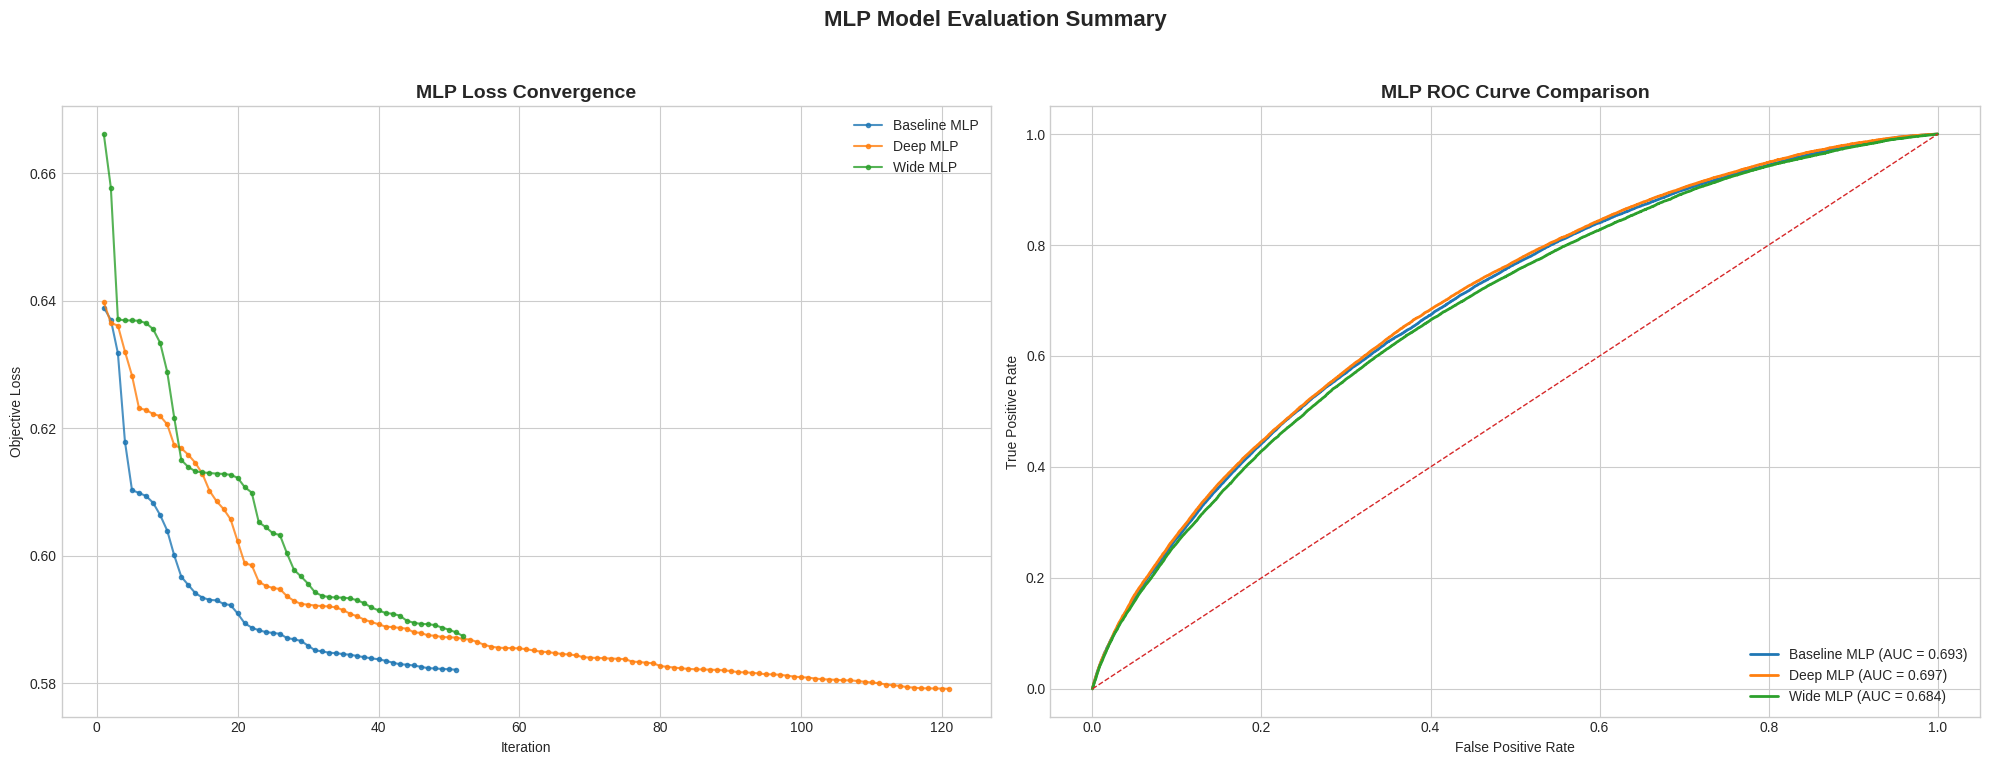

In [0]:

# Set a clean visual style for the plots
plt.style.use("seaborn-v0_8-whitegrid")

# Plot loss curves and ROC curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot loss history for each model, if available
for model_name, loss_values in loss_histories.items():
    if len(loss_values) > 0:
        ax1.plot(
            range(1, len(loss_values) + 1),
            loss_values,
            marker="o",
            markersize=3,
            label=model_name,
            alpha=0.8
        )

ax1.set_title("MLP Loss Convergence", fontsize=14, fontweight="bold")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Objective Loss")
ax1.legend()

# Plot ROC curve for each model
for model_name, model in mlp_models.items():
    predictions = model.transform(test_data)
    predictions, _ = add_positive_score_column(predictions, output_col="p_high_emission")

    eval_pd = (
        predictions
        .select("label", "p_high_emission")
        .toPandas()
        .dropna()
    )

    if eval_pd["label"].nunique() == 2:
        fpr, tpr, _ = roc_curve(eval_pd["label"], eval_pd["p_high_emission"])
        model_auc = auc(fpr, tpr)

        ax2.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{model_name} (AUC = {model_auc:.3f})"
        )

# Add random-classifier reference line
ax2.plot([0, 1], [0, 1], lw=1, linestyle="--")
ax2.set_title("MLP ROC Curve Comparison", fontsize=14, fontweight="bold")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc="lower right")

plt.suptitle("MLP Model Evaluation Summary", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [0]:
# Benchmark model training performance across different data volumes.
# This cell runs the same MLP architecture on a smaller sample and the full training set.
# It measures cache time, model fitting time, total execution time, and approximate CPU/RAM usage.
# The results are saved into a Delta table for reporting and later visualization.

# Create a unique ID for this benchmark run
BENCHMARK_RUN_ID = str(uuid.uuid4())

# Label the current cluster setup for comparison if rerun on another cluster
CLUSTER_CONFIG_LABEL = "current_cluster"


# Safely read Spark configuration values
def safe_spark_conf(key, default="not_available"):
    try:
        return spark.conf.get(key)
    except Exception:
        return default


# Collect useful cluster metadata for the benchmark report
def get_cluster_metadata():
    return {
        "benchmark_run_id": BENCHMARK_RUN_ID,
        "cluster_config_label": CLUSTER_CONFIG_LABEL,
        "spark_app_id": spark.sparkContext.applicationId,
        "spark_master": spark.sparkContext.master,
        "executor_instances": safe_spark_conf("spark.executor.instances"),
        "executor_cores": safe_spark_conf("spark.executor.cores"),
        "executor_memory": safe_spark_conf("spark.executor.memory"),
        "driver_memory": safe_spark_conf("spark.driver.memory"),
        "dynamic_allocation": safe_spark_conf("spark.dynamicAllocation.enabled"),
        "databricks_cluster_id": safe_spark_conf("spark.databricks.clusterUsageTags.clusterId"),
        "databricks_cluster_name": safe_spark_conf("spark.databricks.clusterUsageTags.clusterName"),
        "databricks_num_workers": safe_spark_conf("spark.databricks.clusterUsageTags.clusterWorkers"),
        "databricks_worker_node_type": safe_spark_conf("spark.databricks.clusterUsageTags.clusterNodeType")
    }


# Monitor approximate driver and system CPU/RAM usage during training
class ResourceMonitor:
    def __init__(self, interval_seconds=1.0):
        self.interval_seconds = interval_seconds
        self.rows = []
        self.stop_event = threading.Event()
        self.thread = None

        if PSUTIL_AVAILABLE:
            self.process = psutil.Process(os.getpid())
        else:
            self.process = None

    # Take one CPU/RAM usage sample
    def sample_once(self):
        row = {
            "sample_time": datetime.now().isoformat(),
            "driver_cpu_percent": np.nan,
            "driver_ram_mb": np.nan,
            "system_cpu_percent": np.nan,
            "system_ram_percent": np.nan
        }

        if PSUTIL_AVAILABLE:
            try:
                row["driver_cpu_percent"] = self.process.cpu_percent(interval=None)
                row["driver_ram_mb"] = self.process.memory_info().rss / (1024 ** 2)
                row["system_cpu_percent"] = psutil.cpu_percent(interval=None)
                row["system_ram_percent"] = psutil.virtual_memory().percent
            except Exception:
                pass

        self.rows.append(row)

    # Continue sampling until monitoring is stopped
    def run(self):
        while not self.stop_event.is_set():
            self.sample_once()
            time.sleep(self.interval_seconds)

    # Start resource monitoring in a background thread
    def start(self):
        if PSUTIL_AVAILABLE:
            try:
                self.process.cpu_percent(interval=None)
                psutil.cpu_percent(interval=None)
            except Exception:
                pass

        self.thread = threading.Thread(target=self.run)
        self.thread.daemon = True
        self.thread.start()

    # Stop monitoring and take one final sample
    def stop(self):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join(timeout=5)

        self.sample_once()

    # Summarize average and peak CPU/RAM usage
    def summary(self):
        if len(self.rows) == 0:
            return {
                "driver_cpu_avg_percent": np.nan,
                "driver_cpu_peak_percent": np.nan,
                "driver_ram_peak_mb": np.nan,
                "system_cpu_avg_percent": np.nan,
                "system_cpu_peak_percent": np.nan,
                "system_ram_peak_percent": np.nan
            }

        df = pd.DataFrame(self.rows)

        return {
            "driver_cpu_avg_percent": df["driver_cpu_percent"].mean(),
            "driver_cpu_peak_percent": df["driver_cpu_percent"].max(),
            "driver_ram_peak_mb": df["driver_ram_mb"].max(),
            "system_cpu_avg_percent": df["system_cpu_percent"].mean(),
            "system_cpu_peak_percent": df["system_cpu_percent"].max(),
            "system_ram_peak_percent": df["system_ram_percent"].max()
        }


# Run one stress test for a selected data volume
def run_stress_test(data_fraction, label_name):
    print("=" * 80)
    print(f"Starting Stress Test: {label_name} ({int(data_fraction * 100)}% of data)")
    print("=" * 80)

    # Capture cluster information for this run
    cluster_meta = get_cluster_metadata()

    # Load the prepared MLP dataset
    base_df = spark.table(MLP_PREPARED_TABLE)

    # Use only the training split if the set column exists
    if "set" in base_df.columns:
        base_df = base_df.filter(F.col("set") == "train")

    # Create the benchmark dataset based on the selected data fraction
    if data_fraction < 1.0:
        benchmark_df = base_df.sample(False, data_fraction, seed=SEED)
    else:
        benchmark_df = base_df

    # Persist the benchmark dataset to reduce repeated computation
    benchmark_df = benchmark_df.persist(StorageLevel.MEMORY_AND_DISK)

    # Start resource monitoring
    monitor = ResourceMonitor(interval_seconds=1.0)

    total_start = time.time()
    monitor.start()

    # Count rows to materialize the cached dataset
    cache_start = time.time()
    row_count = benchmark_df.count()
    cache_latency = time.time() - cache_start

    # Use the same simple MLP architecture for every benchmark run
    stress_mlp = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        layers=[INPUT_SIZE, 32, 2],
        maxIter=20,
        seed=SEED
    )

    # Train the model and measure fitting time
    fit_start = time.time()
    stress_model = stress_mlp.fit(benchmark_df)
    fit_latency = time.time() - fit_start

    # Calculate total execution time
    total_latency = time.time() - total_start

    # Stop monitoring and summarize resource usage
    monitor.stop()
    resource_summary = monitor.summary()

    # Release cached benchmark data
    benchmark_df.unpersist()

    # Store all benchmark results in one dictionary
    result = {
        "benchmark_run_id": BENCHMARK_RUN_ID,
        "timestamp": datetime.now().isoformat(),

        "volume_label": label_name,
        "data_fraction": data_fraction,
        "rows": row_count,

        "cache_latency_seconds": cache_latency,
        "fit_latency_seconds": fit_latency,
        "total_latency_seconds": total_latency,

        **resource_summary,
        **cluster_meta
    }

    # Print benchmark summary
    print(f"Rows: {row_count:,}")
    print(f"Cache/materialization latency: {cache_latency:.2f} seconds")
    print(f"MLP fit latency: {fit_latency:.2f} seconds")
    print(f"Total latency: {total_latency:.2f} seconds")
    print(f"Peak driver CPU: {resource_summary['driver_cpu_peak_percent']:.2f}%")
    print(f"Peak driver RAM: {resource_summary['driver_ram_peak_mb']:.2f} MB")
    print(f"Peak system RAM: {resource_summary['system_ram_peak_percent']:.2f}%")

    return result


# Run benchmark tests on 20% and 100% of the training data
stress_results = []

stress_results.append(run_stress_test(0.2, "Small Load - 20%"))
stress_results.append(run_stress_test(1.0, "Full Load - 100%"))

# Convert benchmark results to a Pandas DataFrame
stress_df = pd.DataFrame(stress_results)

# Round numeric columns for cleaner reporting
numeric_cols = [
    "cache_latency_seconds",
    "fit_latency_seconds",
    "total_latency_seconds",
    "driver_cpu_avg_percent",
    "driver_cpu_peak_percent",
    "driver_ram_peak_mb",
    "system_cpu_avg_percent",
    "system_cpu_peak_percent",
    "system_ram_peak_percent"
]

for col in numeric_cols:
    if col in stress_df.columns:
        stress_df[col] = stress_df[col].round(3)


# Save benchmark results to a Delta table
STRESS_TEST_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`mlp_performance_benchmarks`"

spark.createDataFrame(stress_df) \
    .write \
    .format("delta") \
    .mode("append") \
    .option("mergeSchema", "true") \
    .saveAsTable(STRESS_TEST_TABLE)

# Display benchmark results
print("\nFinal Stress Test Results:")
display(stress_df)

print(f"\nSaved benchmark results to: {STRESS_TEST_TABLE}")
print(f"Benchmark Run ID: {BENCHMARK_RUN_ID}")

Starting Stress Test: Small Load - 20% (20% of data)
Rows: 104,554
Cache/materialization latency: 1.46 seconds
MLP fit latency: 16.52 seconds
Total latency: 18.01 seconds
Peak driver CPU: 60.80%
Peak driver RAM: 618.73 MB
Peak system RAM: 49.00%
Starting Stress Test: Full Load - 100% (100% of data)
Rows: 520,276
Cache/materialization latency: 2.86 seconds
MLP fit latency: 59.20 seconds
Total latency: 62.09 seconds
Peak driver CPU: 1.00%
Peak driver RAM: 618.75 MB
Peak system RAM: 49.00%

Final Stress Test Results:


benchmark_run_id,timestamp,volume_label,data_fraction,rows,cache_latency_seconds,fit_latency_seconds,total_latency_seconds,driver_cpu_avg_percent,driver_cpu_peak_percent,driver_ram_peak_mb,system_cpu_avg_percent,system_cpu_peak_percent,system_ram_peak_percent,cluster_config_label,spark_app_id,spark_master,executor_instances,executor_cores,executor_memory,driver_memory,dynamic_allocation,databricks_cluster_id,databricks_cluster_name,databricks_num_workers,databricks_worker_node_type
44effcdc-4424-4563-abaf-2be5d324a548,2026-05-09T10:50:33.962169,Small Load - 20%,0.2,104554,1.46,16.521,18.013,7.337,60.8,618.73,18.374,75.0,49.0,current_cluster,app-20260509084326-0000,spark://10.204.217.98:7077,not_available,not_available,20396m,not_available,not_available,0501-143912-xqtgpxxs,mlp-classic,3,i3.xlarge
44effcdc-4424-4563-abaf-2be5d324a548,2026-05-09T10:51:37.192318,Full Load - 100%,1.0,520276,2.863,59.196,62.088,0.27,1.0,618.75,5.398,66.7,49.0,current_cluster,app-20260509084326-0000,spark://10.204.217.98:7077,not_available,not_available,20396m,not_available,not_available,0501-143912-xqtgpxxs,mlp-classic,3,i3.xlarge



Saved benchmark results to: `new`.`airgreenops`.`mlp_performance_benchmarks`
Benchmark Run ID: 44effcdc-4424-4563-abaf-2be5d324a548


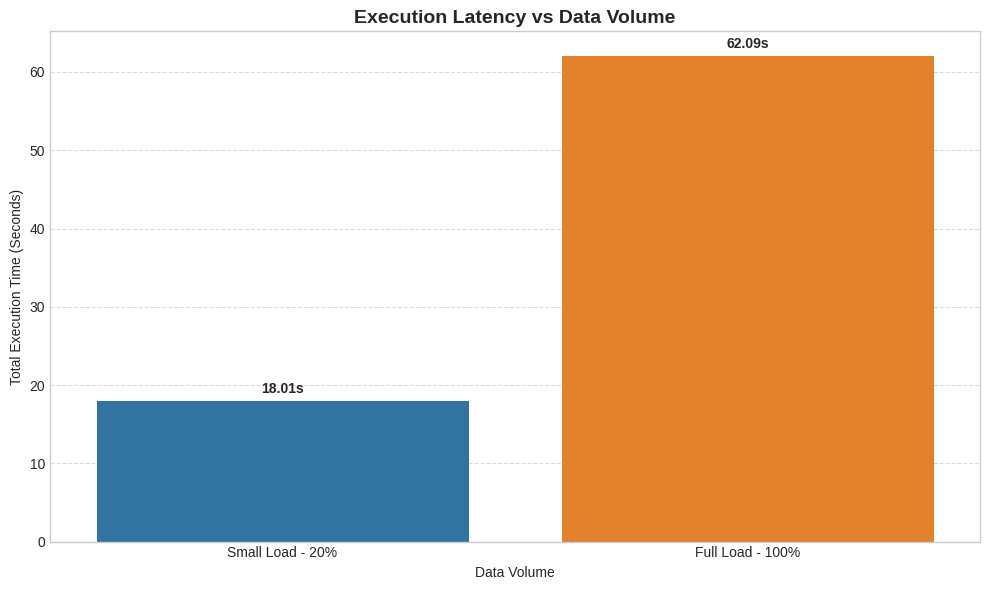

Benchmark visualization completed.


In [0]:
# Visualize benchmark results by comparing execution time across data volumes

# Load the saved benchmark results table
STRESS_TEST_TABLE = f"`{CATALOG}`.`{SCHEMA}`.`mlp_performance_benchmarks`"

stress_df = (
    spark.table(STRESS_TEST_TABLE)
    .orderBy(F.desc("timestamp"))
    .limit(2)
    .toPandas()
)

# Sort rows so smaller load appears before full load
stress_df = stress_df.sort_values("data_fraction")

# Apply a clean chart style
plt.style.use("seaborn-v0_8-whitegrid")

# Use the total execution time column from the benchmark results
latency_col = "total_latency_seconds"

# Create the bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=stress_df,
    x="volume_label",
    y=latency_col,
    hue="volume_label",
    legend=False
)

# Add time values above each bar
for i, val in enumerate(stress_df[latency_col]):
    plt.text(
        i,
        val + 1,
        f"{val:.2f}s",
        ha="center",
        fontweight="bold"
    )

# Add title and axis labels
plt.title("Execution Latency vs Data Volume", fontsize=14, fontweight="bold")
plt.xlabel("Data Volume")
plt.ylabel("Total Execution Time (Seconds)")

# Add grid lines for easier comparison
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Improve layout spacing
plt.tight_layout()

# Display the chart
plt.show()

# Confirm that the visualization has been generated
print("Benchmark visualization completed.")